In [1]:
import gym
import d4rl
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

from dm_control import suite


device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28


'cuda'

In [2]:
NUM_TRAJECTORIES = 10000
TRAJECTORY_LEN = 1000

In [3]:
# def return_range(dataset, max_episode_steps):
#     returns, lengths = [], []
#     ep_ret, ep_len = 0., 0
#     for i in tqdm(range(dataset['rewards'].shape[0])):
#     # for r, d in tqdm(zip(dataset['rewards'], dataset['terminals'])):
#         r, d = dataset['rewards'][i].item(), dataset['terminals'][i].item()
#         ep_ret += float(r)
#         ep_len += 1
#         if d or ep_len == max_episode_steps:
#             returns.append(ep_ret)
#             lengths.append(ep_len)
#             ep_ret, ep_len = 0., 0
#     # returns.append(ep_ret)    # incomplete trajectory
#     lengths.append(ep_len)      # but still keep track of number of steps
#     assert sum(lengths) == len(dataset['rewards'])
#     return min(returns), max(returns)


def return_range(dataset):
    r = dataset['rewards'].reshape(NUM_TRAJECTORIES, TRAJECTORY_LEN-1).sum(axis=1)
    return r.max().item(), r.min().item()

def get_env_and_dataset(env_name, max_episode_steps=1000):
    env = gym.make(env_name)
    dataset = d4rl.qlearning_dataset(env)

    if any(s in env_name for s in ('halfcheetah', 'hopper', 'walker2d')):
        min_ret, max_ret = return_range(dataset, max_episode_steps)
        dataset['rewards'] /= (max_ret - min_ret)
        dataset['rewards'] *= max_episode_steps
    elif 'antmaze' in env_name:
        dataset['rewards'] -= 1.

    for k, v in dataset.items():
        dataset[k] = torch.from_numpy(v).to(device)

    return env, dataset

In [54]:

ENV_NAME = 'cheetah' # walker | cheetah
POLICY_EXTRACTION_METHOD = 'awr' # awr |  ddpg 
TRAINING_STEPS = 1_000_000
BATCH_SIZE = 1024

config = {
    'expectile': 0.9,
    'temperature': 10.0,
    'discount': 0.99,
    'tau': 0.005,
    
    'bc_coefficient': 0.01
}

print(config)


# In[3]:


if ENV_NAME == 'walker':
    STATE_DIM = 24
    ACTION_DIM = 6
    env = suite.load(
        domain_name='walker',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/walker_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_walker.npy')


elif ENV_NAME == 'cheetah':
    STATE_DIM = 17
    ACTION_DIM = 6
    env = suite.load(
        domain_name='cheetah',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/cheetah_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_cheetah.npy')

{'expectile': 0.9, 'temperature': 10.0, 'discount': 0.99, 'tau': 0.005, 'bc_coefficient': 0.01}


In [56]:
class VelocityRewardFunctionWalker:
    def __init__(self):
        pass    

    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'gaussian':
            scale = np.sqrt(-2 * np.log(value_at_1))
            return np.exp(-0.5 * (x*scale)**2)

        elif sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='gaussian', value_at_margin=0.1):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return torch.tensor(value)
    
    def compute_reward(self, states, params):
        
        if isinstance(params, int) or isinstance(params, float):
            params = torch.full((*states.shape[:-1], 1), fill_value=params)
        
        assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

        _STAND_HEIGHT = 1.2
        horizontal_velocity = states[..., 0:1]
        torso_upright = states[..., 1:2]
        torso_height = states[..., 2:3]
        standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
        upright = (1 + torso_upright) / 2
        stand_reward = (3*standing + upright) / 4
        move_reward = self.tolerance(horizontal_velocity,
                                        lower=params,
                                        upper=float('inf'),
                                        margin=params/2,
                                        value_at_margin=0.5,
                                        sigmoid='linear')
        # move_reward[params == 0] = stand_reward[params == 0]
        rew = stand_reward * (5*move_reward + 1) / 6
        # rew = (5*move_reward + 1) / 6
        
        return torch.tensor(rew[..., 0])


class VelocityRewardFunctionCheetah:
    def __init__(self):
        pass    
    
    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
        else:
            raise NotImplementedError
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='linear', value_at_margin=0):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return value
    
    def compute_reward(self, states, params):
        
        if isinstance(params, int):
            params = torch.full((*states.shape[:-1], 1), fill_value=params)
        
        assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

        horizontal_velocity = states[..., 0:1]
        sign_of_param = np.sign(params)
        horizontal_velocity = horizontal_velocity * sign_of_param
        rew = self.tolerance(horizontal_velocity,
                             lower=np.abs(params),
                             upper=float('inf'),
                             margin=np.abs(params),
                             value_at_margin=0,
                             sigmoid='linear')
        
        return torch.tensor(rew[..., 0], dtype=torch.float32)
    
  
if ENV_NAME == 'walker':
    velocity_reward_function = VelocityRewardFunctionWalker()

    def reward_function(state):
        return velocity_reward_function.compute_reward(state, 8)
  
  
elif ENV_NAME == 'cheetah':
    velocity_reward_function = VelocityRewardFunctionCheetah()

    def reward_function(state):
        return velocity_reward_function.compute_reward(state, 10)

In [57]:
dataset_ = {}
dataset_['observations'] = dataset['observations'][:, :-1, :].reshape(-1, STATE_DIM)
dataset_['next_observations'] = dataset['observations'][:, 1:, :].reshape(-1, STATE_DIM)
dataset_['actions'] = dataset['actions'][:, :-1].reshape(-1, ACTION_DIM)
dataset_['terminals'] = dataset['terminals'][:, :-1].reshape(-1)

dataset_['rewards'] = reward_function(
    torch.tensor(aux.reshape(NUM_TRAJECTORIES, TRAJECTORY_LEN, aux.shape[-1])[:, 1:].reshape(-1, aux.shape[-1]))
).numpy()

dataset = dataset_ 

In [60]:
keys = list(dataset.keys())
for k in keys:
    if k not in ['observations', 'next_observations', 'actions', 'terminals', 'rewards']:
        del dataset[k]
    else:
        dataset[k] = torch.tensor(dataset[k]).to(device)

In [61]:
max_ret, min_ret = return_range(dataset)
dataset['rewards'] /= (max_ret - min_ret)
dataset['rewards'] *= TRAJECTORY_LEN

obs_dim = dataset['observations'].shape[1]
act_dim = dataset['actions'].shape[1] 

In [65]:
class Squeeze(nn.Module):
    def __init__(self, dim=None):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        return x.squeeze(dim=self.dim)

def mlp(dims, activation=nn.ReLU, output_activation=None, squeeze_output=False):
    n_dims = len(dims)
    assert n_dims >= 2, 'MLP requires at least two dims (input and output)'

    layers = []
    for i in range(n_dims - 2):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        layers.append(activation())
    layers.append(nn.Linear(dims[-2], dims[-1]))
    if output_activation is not None:
        layers.append(output_activation())
    if squeeze_output:
        assert dims[-1] == 1
        layers.append(Squeeze(-1))
    net = nn.Sequential(*layers)
    net.to(dtype=torch.float32)
    return net

In [66]:
from torch.distributions import MultivariateNormal

LOG_STD_MIN = -5.0
LOG_STD_MAX = 2.0

class GaussianPolicy(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_dim=256, n_hidden=2):
        super().__init__()
        self.net = mlp([obs_dim, *([hidden_dim] * n_hidden), act_dim])
        self.log_std = nn.Parameter(torch.zeros(act_dim, dtype=torch.float32))

    def forward(self, obs):
        mean = self.net(obs)
        std = torch.exp(self.log_std.clamp(LOG_STD_MIN, LOG_STD_MAX))
        scale_tril = torch.diag(std)
        return MultivariateNormal(mean, scale_tril=scale_tril)


    def act(self, obs, deterministic=False, enable_grad=False):
        with torch.set_grad_enabled(enable_grad):
            dist = self(obs)
            return dist.mean if deterministic else dist.sample()
        
        
class TwinQ(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256, n_hidden=2):
        super().__init__()
        dims = [state_dim + action_dim, *([hidden_dim] * n_hidden), 1]
        self.q1 = mlp(dims, squeeze_output=True)
        self.q2 = mlp(dims, squeeze_output=True)

    def both(self, state, action):
        sa = torch.cat([state, action], 1)
        return self.q1(sa), self.q2(sa)

    def forward(self, state, action):
        return torch.min(*self.both(state, action))


class ValueFunction(nn.Module):
    def __init__(self, state_dim, hidden_dim=256, n_hidden=2):
        super().__init__()
        dims = [state_dim, *([hidden_dim] * n_hidden), 1]
        self.v = mlp(dims, squeeze_output=True)

    def forward(self, state):
        return self.v(state)

In [67]:
import copy
from torch.optim.lr_scheduler import CosineAnnealingLR


class IQL(nn.Module):
    def __init__(self, critic, value, policy, optimizer_factory, max_steps):
        super().__init__()
        self.critic = critic.to(device)
        self.target_critic = copy.deepcopy(critic).requires_grad_(False).to(device)
        self.value = value.to(device)
        self.policy = policy.to(device)
        self.v_optimizer = optimizer_factory(self.value.parameters())
        self.q_optimizer = optimizer_factory(self.critic.parameters())
        self.policy_optimizer = optimizer_factory(self.policy.parameters())
        self.policy_lr_schedule = CosineAnnealingLR(self.policy_optimizer, max_steps)

In [68]:
config = {
    'expectile': 0.8,
    'temperature': 3.0,
    'discount': 0.99,
    'tau': 0.005,
}

In [69]:
def asymmetric_l2_loss(u, tau):
    return torch.mean(torch.abs(tau - (u < 0).float()) * u**2)

def update_exponential_moving_average(target, source, alpha):
    for target_param, source_param in zip(target.parameters(), source.parameters()):
        target_param.data.mul_(1. - alpha).add_(source_param.data, alpha=alpha)

def sample_batch(dataset, batch_size):
    k = list(dataset.keys())[0]
    n, device = len(dataset[k]), dataset[k].device
    for v in dataset.values():
        assert len(v) == n, 'Dataset values must have same length'
    indices = torch.randint(low=0, high=n, size=(batch_size,), device=device)
    return {k: v[indices].float() for k, v in dataset.items()}

In [70]:
def smooth_and_downsample(losses, smoothing=0.9, max_points=100):
    if not losses: return []
    smoothed = [losses[0]]
    for loss in losses[1:]:
        smoothed.append(smoothing * smoothed[-1] + (1 - smoothing) * loss)
    downsample = max(1, len(smoothed) // max_points)  # Ensure at least 1
    return smoothed[::downsample]


def evaluate_policy(env, iql_agent, max_episode_steps=1000):
    obs = env.reset()
    total_reward = 0.
    for _ in range(max_episode_steps):
        with torch.no_grad():
            obs = torch.tensor(obs, device=device, dtype=torch.float)
            action = iql_agent.policy.act(obs, deterministic=True).cpu().numpy()
        next_obs, reward, done, info = env.step(action)
        total_reward += reward
        if done:
            break
        else:
            obs = next_obs
    return total_reward

In [71]:
policy = GaussianPolicy(obs_dim, act_dim).to(device)
critic = TwinQ(obs_dim, act_dim)
value = ValueFunction(obs_dim)

iql_agent = IQL(
    critic=critic,
    value=value,
    policy=policy,
    optimizer_factory=lambda params: torch.optim.Adam(params, lr=3e-4),
    max_steps=10**6,
)

actor_losses = []
v_losses = []
q_losses = []
rewards_logs = []

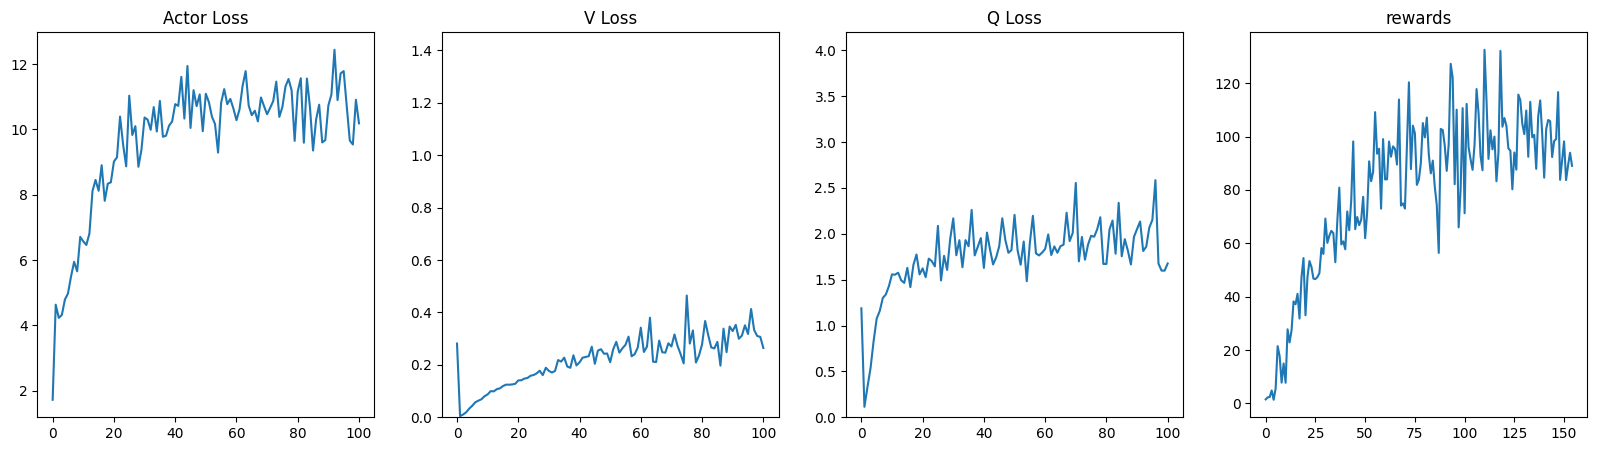

  0%|          | 2809/1000000 [00:14<1:27:36, 189.70it/s]


KeyboardInterrupt: 

In [106]:
for timestep in tqdm(range(10**6)):

    batch = sample_batch(dataset, 256)


    observations, next_observations, actions, terminals, rewards = batch.values()

    with torch.no_grad():
        target_q = iql_agent.target_critic(observations, actions)
        next_v = iql_agent.value(next_observations)

    # Update value function
    v = iql_agent.value(observations)
    adv = target_q - v
    v_loss = asymmetric_l2_loss(adv, config['expectile'])
    iql_agent.v_optimizer.zero_grad(set_to_none=True)
    v_loss.backward()
    iql_agent.v_optimizer.step()



    # Update Q function
    targets = rewards + (1. - terminals.float()) * config['discount'] * next_v.detach()
    qs = iql_agent.critic.both(observations, actions)
    q_loss = sum(F.mse_loss(q, targets) for q in qs) / len(qs)
    iql_agent.q_optimizer.zero_grad(set_to_none=True)
    q_loss.backward()
    iql_agent.q_optimizer.step()

    # Update target Q network
    update_exponential_moving_average(iql_agent.target_critic, iql_agent.critic, config['tau'])

    # Update policy
    exp_adv = torch.exp(config['temperature'] * adv.detach()).clamp(max=100.)
    policy_out = iql_agent.policy(observations)
    if isinstance(policy_out, torch.distributions.Distribution):
        bc_losses = -policy_out.log_prob(actions)
    elif torch.is_tensor(policy_out):
        assert policy_out.shape == actions.shape
        bc_losses = torch.sum((policy_out - actions)**2, dim=1)
    else:
        raise NotImplementedError
    policy_loss = torch.mean(exp_adv * bc_losses)
    iql_agent.policy_optimizer.zero_grad(set_to_none=True)
    policy_loss.backward()
    iql_agent.policy_optimizer.step()
    iql_agent.policy_lr_schedule.step()
    
    
    
    actor_losses.append(policy_loss.item())
    v_losses.append(v_loss.item())
    q_losses.append(q_loss.item())
    
    # break
    
    if timestep % 5000 == 0:
        
        # eval_returns = np.array([evaluate_policy(env, iql_agent) for _ in range(10)])
        # normalized_returns = d4rl.get_normalized_score(ENV_NAME, eval_returns) * 100.0
        
        produced_trajectory, produced_trajectory_physics, eval_rewards = run_test(iql_agent, num_evals=10)
        # if ENV_NAME == 'walker':
        #     r = reward_function(torch.tensor(produced_trajectory[:, :, -3:]))
        # elif ENV_NAME == 'cheetah':
        #     r = reward_function(torch.tensor(produced_trajectory[:, :, -1:]))
            
        # r_mean = r.sum(dim=1).mean().item()
        
        r_mean = eval_rewards.mean()
        rewards_logs.append(r_mean)
        
        clear_output(True)
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        
        axs[0].plot(smooth_and_downsample(actor_losses))
        axs[1].set_ylim(0,max(actor_losses[-100:]))
        axs[0].set_title("Actor Loss")
        
        axs[1].plot(smooth_and_downsample(v_losses))
        axs[1].set_ylim(0,max(v_losses[-100:]))
        axs[1].set_title("V Loss")
        
        axs[2].plot(smooth_and_downsample(q_losses))
        axs[2].set_ylim(0,max(q_losses[-100:]))
        axs[2].set_title("Q Loss")
        
        axs[3].plot(rewards_logs)
        axs[3].set_title("rewards")
        
        plt.show()

In [88]:

def timestep2obs(timestep):
    obs = np.concatenate([v if len(v.shape) != 0 else v.reshape(-1) for k, v in timestep.observation.items()])
    return obs

def run_test(iql_agent, num_evals):


    produced_trajectories = []
    produced_trajectories_physics = []
    
    
    rewards = []
    
    for _ in range(num_evals):
        
        timestep = env.reset()        
        state = timestep2obs(timestep)
        # state = normalize_dataset_coords(state)
    
        produced_trajectory = []   
        produced_trajectory_physics = [] 

        episode_rewards = []

        for step in tqdm(range(1000)):
        # for step in range(1000):
            
            physics = env.physics.get_state()
            
            produced_trajectory_physics.append(physics)
            
            if ENV_NAME == 'walker':
                horizontal_velocity = env.physics.horizontal_velocity()
                torso_upright = env.physics.torso_upright()
                torso_height = env.physics.torso_height()
                aux = np.array([horizontal_velocity, torso_upright, torso_height])

            elif ENV_NAME == 'cheetah':
                horizontal_velocity = env.physics.speed()
                aux = np.array([horizontal_velocity])
            
            observation_aux = np.concatenate([state, aux])
            
            produced_trajectory.append(observation_aux)
            
            
            with torch.no_grad():
                tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()
                                
                # dist = iql_agent.get_actor(tensor_state)
                # action = dist.loc.cpu()
                # action = np.array(action[0]).clip(-1, 1)
                
                action = iql_agent.policy.act(tensor_state, deterministic=True).cpu().numpy()

            timestep = env.step(action)
            
            next_state = timestep2obs(timestep)
            # state = normalize_dataset_coords(next_state)
            state = next_state
            
            episode_rewards.append(timestep.reward)
        
        rewards.append(np.sum(episode_rewards))
            
        produced_trajectory = np.stack(produced_trajectory)
        produced_trajectory_physics = np.stack(produced_trajectory_physics)
                
        produced_trajectories.append(produced_trajectory)
        produced_trajectories_physics.append(produced_trajectory_physics)
    
    produced_trajectories = np.stack(produced_trajectories)
    produced_trajectories_physics = np.stack(produced_trajectories_physics)
    

    return produced_trajectories, produced_trajectories_physics, np.array(rewards)



In [103]:
_, _, eval_rewards = run_test(iql_agent, num_evals=10)

100%|██████████| 1000/1000 [00:00<00:00, 2857.14it/s]


In [104]:
eval_rewards.mean()

97.87220168796571